<a href="https://colab.research.google.com/github/Nkeeydata/HR_Attrition-Analysis/blob/main/RickyHR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROBLEM STATEMENT**

The HR department at Ricky Enterprise wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### COLUMN NAMES AND MEANING

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## *IMPORTATION OF LIBRARIES*

In [ ]:
#importing of operational libraries
import pandas as pd
import numpy as np

#importing of visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

#importation of machine learning libraries
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

#importation of the save library
import joblib

In [ ]:
#Loading of our dataset

df = pd.read_csv('HR_comma_sep.csv')

In [ ]:
df.head() # viewing the first five rows

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## DATA EXPLORATION

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


#### Above code ```df.info()``` illustrate the number of rows and columns in our dataset, the number of null-none columns, as well as the datatypes, which shows float(2), integer(6), and object(2)

In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


#### The df.describe() tries to review to us the summary statistics of our dataset showing us the **mean**, **median**, **standard deviation**, and other mathematical variables

In [ ]:
df.isna().sum() #reviewing number of mising valuse

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [ ]:
df.duplicated().sum() #reviewing the number of duplicates

3008

#### We have about 3008 duplicates in he above datasets, and would be removed after probing further

In [ ]:
df[df.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


The above output shows the first five occurences of rows that are duplicated farther down in the dataframe. How likely is it that these are legitimate entries? In other words, how plausible is it that two employees self-reported the exact same response for every column?

You could perform a likelihood analysis by essentially applying Bayes' theorem and multiplying the probabilities of finding each value in each column, but this does not seem necessary. With several continuous variables across 10 columns, it seems very unlikely that these observations are legitimate. You can proceed by dropping them.

In [ ]:
df1 = df.copy() # making a duplicate of the original dataset before dropping

In [ ]:
df.drop_duplicates(keep='first', inplace = True)

In [ ]:
df.duplicated().sum() #confirming the removal of the duplicates

0

### RENAMING OUR COLUMNS FOR PROPER NAMING RULES

In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
df.rename(columns={'satisfaction_level':'sat_level',
                   'last_evaluation':'last_eva',
                   'average_montly_hours':'average_monthly_hours',
                   'time_spend_company':'tenure',
                   'Work_accident':'work_accident',
                   'Department':'department'},
         inplace = True)



### CHECKING FOR OUTLIERS

In [ ]:
df.columns

Index(['sat_level', 'last_eva', 'number_project', 'average_monthly_hours',
       'tenure', 'work_accident', 'left', 'promotion_last_5years',
       'department', 'salary'],
      dtype='object')

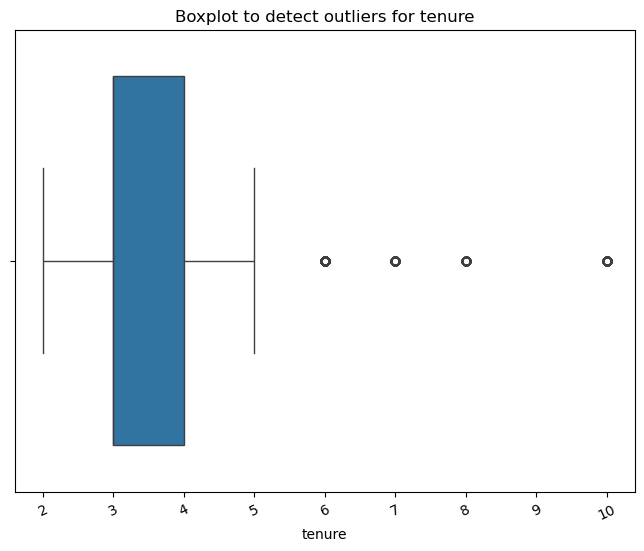

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
sns.boxplot(x=df['tenure'])
plt.xticks(rotation = 25)
plt.show()

#### The boxplot above shows there are outliers in the ```tenure``` column, further probing will be encouraged

#### Further Probing of the outlier to get a better understanding of what the data is saying

In [ ]:
# Compute the 25th percentile value in `tenure`
per25th = df['tenure'].quantile(0.25)

# Compute the 75th percentile value in `tenure`
per75th = df['tenure'].quantile(0.75)

# Compute the interquartile range in `tenure`
iqr = per75th - per25th

In [ ]:
# Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = per75th + 1.5 * iqr
lower_limit = per25th - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: 1.5
Upper limit: 5.5


#### The values for lower and upper limits shows that our values should fall between 1.5 and 5.5 to be accepted and not addressed as an outlier

In [ ]:
# Identify subset of data containing outliers in `tenure`
outliers = df[(df['tenure'] > upper_limit) | (df['tenure'] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Number of rows in the data containing outliers in `tenure`: 824


In [ ]:
# Get numbers of people who left vs. stayed

print(df['left'].value_counts())
print()

left
0    10000
1     1991
Name: count, dtype: int64



#### This shows that about ```10,000``` people stayed in the company, while ```1,991``` left

In [ ]:
# Percentages of people who left vs. stayed

print(df['left'].value_counts(normalize=True) * 100)

left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


#### We recorded about 83% of people who agreed to stay, and 16% left

## DATA VISUALIZATIONS

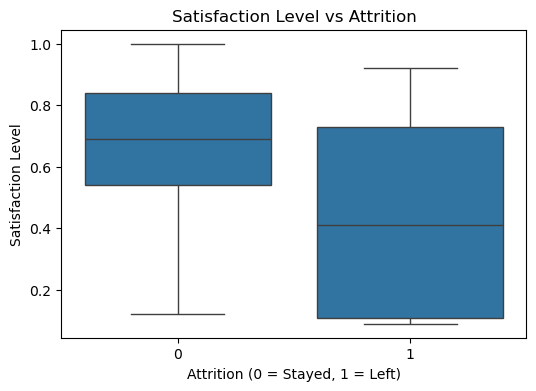

In [ ]:
# Boxplot: Satisfaction level grouped by left

plt.figure(figsize=(6,4))
sns.boxplot(x="left", y="sat_level", data=df)
plt.title("Satisfaction Level vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Satisfaction Level")
plt.show()

#### We could deduce that employees with high satisfaction level stayed, whereas the employees with lower satisfaction level left

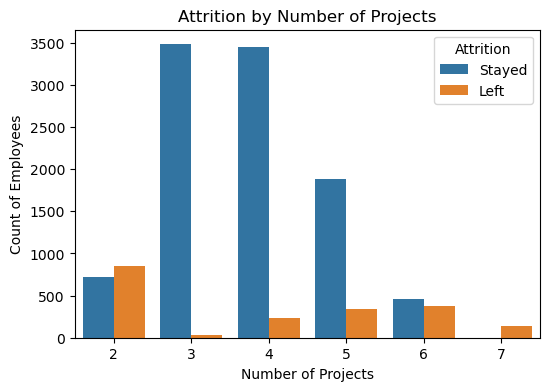

In [ ]:
# Bar chart: Attrition rates by number of projects
plt.figure(figsize=(6,4))
sns.countplot(x="number_project", hue="left", data=df)
plt.title("Attrition by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Count of Employees")
plt.legend(title="Attrition", labels=["Stayed", "Left"])
plt.show()

#### We could see that employees with highest number of projects, 7 in this circumstance, left.

The chart reviews to us the relationship between number of projects done by employees and whether they left or not

In [ ]:
# Lets get the total value of employees who left for employees with 7 projects seeing that none stayed

df[df['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

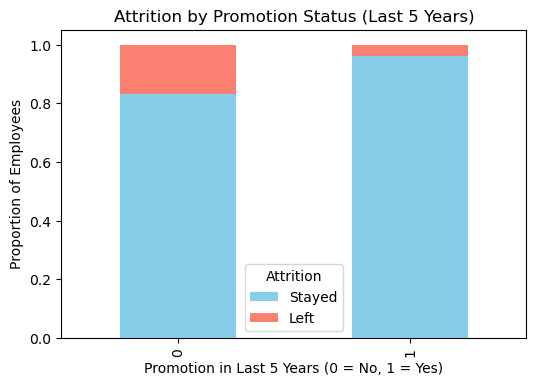

In [ ]:
# Stacked bar chart: Attrition by promotion status
promotion_attrition = pd.crosstab(df["promotion_last_5years"], df["left"], normalize="index")

promotion_attrition.plot(kind="bar", stacked=True, color=["skyblue","salmon"], figsize=(6,4))
plt.title("Attrition by Promotion Status (Last 5 Years)")
plt.xlabel("Promotion in Last 5 Years (0 = No, 1 = Yes)")
plt.ylabel("Proportion of Employees")
plt.legend(title="Attrition", labels=["Stayed", "Left"])
plt.show()

#### It could be seen from the stacked chart above that we recorded more staffs that left from the employees that were not promoted in the last 5 years, while little left from the employees that have been promoted within the last 5 years

In [ ]:
# Display counts for each department
df["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

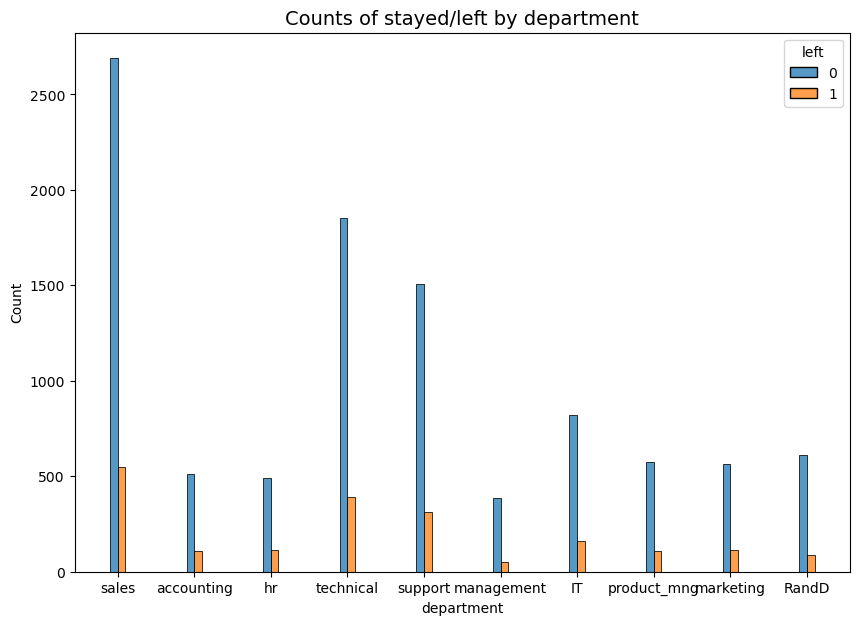

In [ ]:
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't

plt.figure(figsize=(10,7))
sns.histplot(data=df, x='department', hue='left', discrete=1,
             hue_order=[0, 1], multiple='dodge', shrink=.2)
plt.title('Counts of stayed/left by department', fontsize=14);

#### the chart above shows that ```sales``` department has the highest number of employees and also the highest number of employees that left, but we will calculate the percentage to get the highest in relation to their total number

In [ ]:
# Crosstab: department vs. attrition (left)

dept_attrition = pd.crosstab(df['department'], df['left'], normalize='index') * 100

# Rename columns for clarity
dept_attrition.columns = ['Stayed (%)', 'Left (%)']

print(dept_attrition.round(2))


             Stayed (%)  Left (%)
department                       
IT                83.81     16.19
RandD             87.75     12.25
accounting        82.45     17.55
hr                81.20     18.80
management        88.07     11.93
marketing         83.36     16.64
product_mng       83.97     16.03
sales             83.02     16.98
support           82.87     17.13
technical         82.62     17.38


#### Above shows that HR has the highest percentage of employees who left despite sales having more number of employees that both stayed and left

In [ ]:
df1 = df.drop(columns = ['department', 'salary'])# dropping the categorical variable before conducting my heatmap

### HEATMAP COMPILATION

In [ ]:
df1.columns

Index(['sat_level', 'last_eva', 'number_project', 'average_monthly_hours',
       'tenure', 'work_accident', 'left', 'promotion_last_5years'],
      dtype='object')

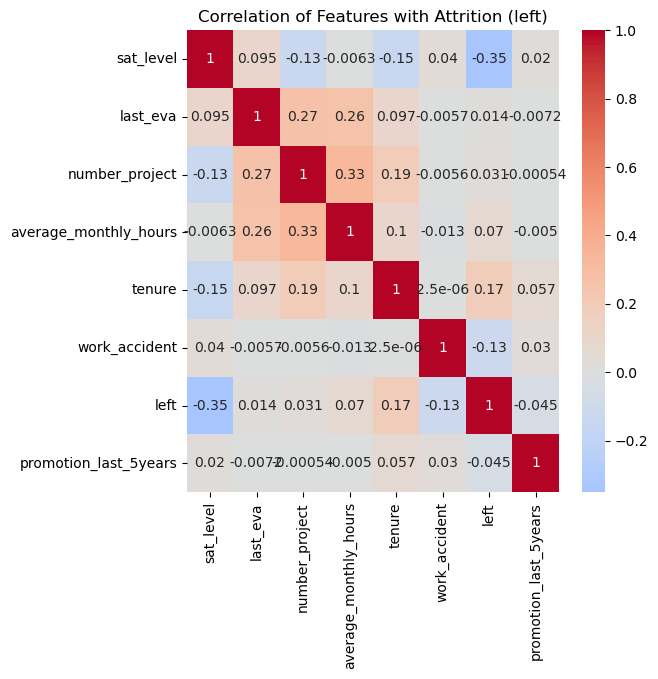

In [ ]:
# Compute correlation matrix
corr = df1.corr()


plt.figure(figsize=(6,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Features with Attrition (left)")
plt.show()

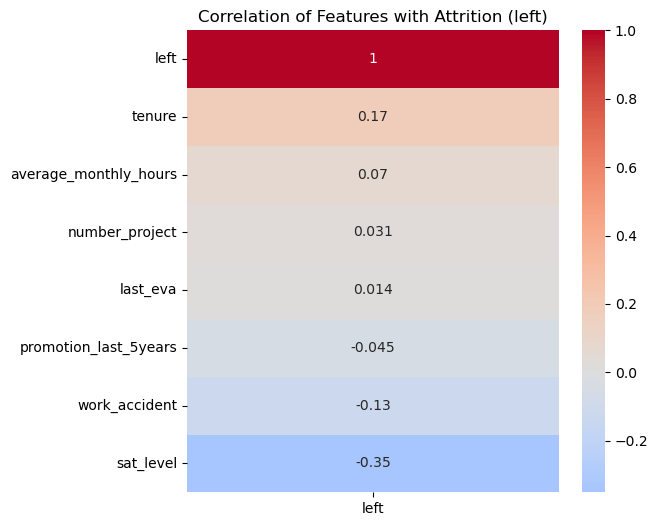

In [ ]:
# Focus only on correlations with the target variable 'left'
target_corr = corr[['left']].sort_values(by='left', ascending=False)

plt.figure(figsize=(6,6))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Features with Attrition (left)")
plt.show()

#### We could see that ```satisfaction_level is a high determinant of whether an employee will leave of stay in the company

### INSIGHTS

It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. It can be ungratifying to work long hours and not receive promotions or good evaluation scores. There's a sizeable group of employees at this company who are probably burned out. It also appears that if an employee has spent more than six years at the company, they tend not to leave.

## MODEL BUILDING

#### Logistic Regression

Before splitting the data, encode the non-numeric variables. There are two: department and salary.


department is a categorical variable, which means you can dummy it for modelin
g.

salary is categorical too, but it's ordinal. There's a hierarchy to the categories, so it's better not to dummy this column, but rather to convert the levels to numbers, 0–2.

In [ ]:
df.shape

(11991, 10)

In [ ]:
df_en = df.copy() #duplicating the DataFrame

# Encode the `salary` column as an ordinal numeric category
df_en['salary'] = (
    df_en['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_en = pd.get_dummies(df_en, drop_first=False)

# Display the new dataframe
df_en.head()

,sat_level,last_eva,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


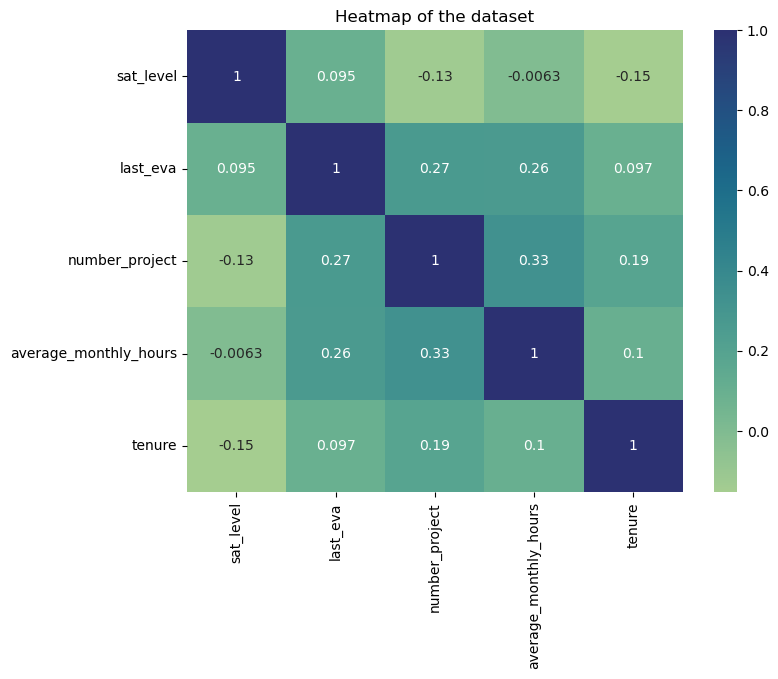

In [ ]:
# Create a heatmap to visualize how correlated variables are

plt.figure(figsize=(8, 6))
sns.heatmap(df_en[['sat_level', 'last_eva', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Example: select only the predictors you want to check
X = df[['sat_level', 'last_eva', 'number_project',
        'average_monthly_hours', 'tenure']]

# Add a constant (intercept) for statsmodels
X = add_constant(X)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)


                 feature        VIF
0                  const  41.608335
1              sat_level   1.058663
2               last_eva   1.144426
3         number_project   1.223627
4  average_monthly_hours   1.168686
5                 tenure   1.061488


#### Due to the fact that all variables have VIF less than 2, it shows there are no collinearity among the variables. Will therefore work with all in building my model

## MODEL TRAINING AND EVALUATION

#### Since we are working with Logistic Regression, and it doesn't work well with outlier, we will be dropping the columns that have outliers in the ```tenure``` column

In [ ]:
# creating a new DataFrame without outliers in the tenure column

df_log = df_en[(df_en['tenure'] >= lower_limit) & (df_en['tenure'] <= upper_limit)]

In [ ]:
df_log.shape

(11167, 19)

In [ ]:
# confirming the number of outlier in `tenure` as zero
outlier1 = df_log[(df_log['tenure'] > upper_limit) | (df_log['tenure'] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outlier1))

Number of rows in the data containing outliers in `tenure`: 0


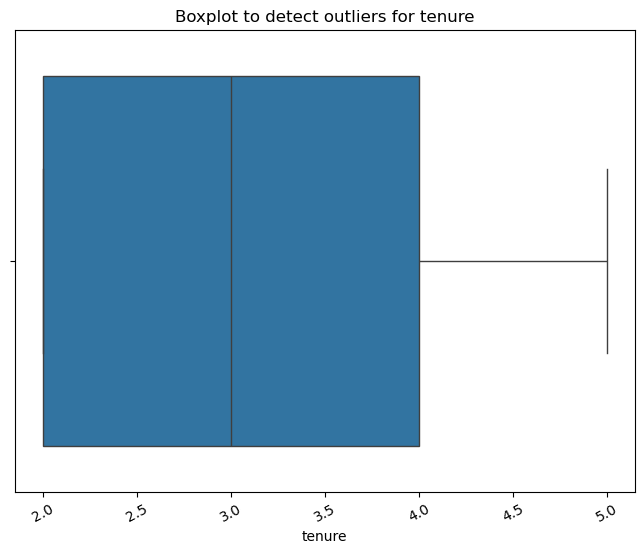

In [ ]:
# confirming no outlier in the tenure column using boxplot visualization

plt.figure(figsize=(8,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
sns.boxplot(x=df_log['tenure'])
plt.xticks(rotation = 28)
plt.show()

In [ ]:
# Creating your X and y variables

X = df_log.drop('left', axis = 1)
y = df_log['left']

In [ ]:
# Separating into train and test DataFrame

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = .25, stratify = y, random_state = 42)

In [ ]:
# confirming their size and length

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8375, 18) (2792, 18) (8375,) (2792,)


In [ ]:
# instantiating the logistic regression model

log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = log_reg.predict(X_test) # predicting using the model

In [ ]:
df_log['left'].value_counts(normalize = True) * 100 #percentages of class balances

left
0    83.146772
1    16.853228
Name: proportion, dtype: float64

There is an approximately 83%-17% split. So the data is not perfectly balanced, but it is not too imbalanced. If it was more severely imbalanced, we might want to resample the data to make it more balanced. In this case, we can use this data without modifying the class balance and continue evaluating the model.

In [ ]:
# Create classification report for logistic regression model

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.93      0.90      2321
           1       0.44      0.26      0.33       471

    accuracy                           0.82      2792
   macro avg       0.65      0.60      0.61      2792
weighted avg       0.79      0.82      0.80      2792



The classification report above shows that the logistic regression model achieved a precision of 79%, recall of 82%, f1-score of 80% (all weighted averages), and accuracy of 82%. However, if it's most important to predict employees who leave, then the scores are significantly lower.

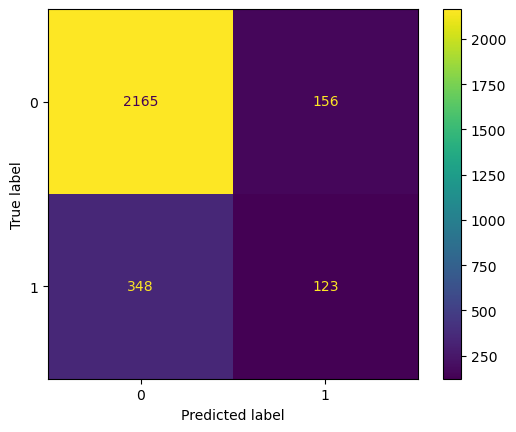

In [ ]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm,
                                  display_labels=log_reg.classes_)

# Plot confusion matrix
log_disp.plot(values_format='')

# Display plot
plt.show()

The upper-left quadrant displays the number of true negatives.
The upper-right quadrant displays the number of false positives.
The bottom-left quadrant displays the number of false negatives.
The bottom-right quadrant displays the number of true positives.

True negatives: The number of people who did not leave that the model accurately predicted did not leave.

False positives: The number of people who did not leave the model inaccurately predicted as leaving.

False negatives: The number of people who left that the model inaccurately predicted did not leave

True positives: The number of people who left the model accurately predicted as leaving

A perfect model would yield all true negatives and true positives, and no false negatives or false positives.

### INSIGHTS FOR STAKEHOLDERS from the LOGISTIC REGRESSION MODEL


The model is good at identifying who will stay, but poor at spotting who will leave.

This means attrition risk is being underestimated.

Executives should not rely on this model alone to flag employees at risk of leaving.

Attrition prediction is the harder problem.

Employees who leave may have more complex, less obvious signals.

Current features (satisfaction, hours, promotions, etc.) may not fully capture the drivers of turnover.

Business implication:

If used operationally, the model will overpredict retention and underpredict attrition.

That could lead to missed opportunities for intervention (e.g., failing to support employees who are at risk of leaving).

### PLEASE TAKE NOTE

Our current attrition model is reliable at confirming who will stay but weak at identifying who will leave. To make it actionable for retention strategy, we need to rebalance the data, enrich features, and optimize specifically for predicting leavers. Otherwise, we risk missing the employees most in need of intervention.

### BUILDING OTHER MODELS LIKE DECISION TREES AND RANDOM FOREST

### DECISON TREE MODEL

In [ ]:
# Split the data

X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [ ]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [ ]:
# Convert all boolean columns to 0/1 integers
X_train = X_train.astype({col: int for col in X_train.select_dtypes(include='bool').columns})
X_test  = X_test.astype({col: int for col in X_test.select_dtypes(include='bool').columns})


In [ ]:
X_train.head() # confirming that all our variables are numeric

,sat_level,last_eva,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
9784,0.43,0.81,3,102,3,0,0,1,0,0,0,0,0,0,0,1,0,0
6535,0.74,0.68,3,206,2,1,0,1,0,0,0,0,0,0,0,0,1,0
5217,0.87,0.50,4,267,2,1,0,1,0,0,1,0,0,0,0,0,0,0
8421,0.61,0.56,2,123,2,0,0,1,0,0,0,0,0,0,0,1,0,0
6134,0.65,0.79,4,196,2,0,0,1,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Fitting the tree into the model

tree1.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
# Check best parameters
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [ ]:
# Check best AUC score on CV
tree1.best_score_

0.9738070859906354

In [ ]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc

    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })

    return table

In [ ]:
# Get all CV scores
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.959115,0.912839,0.935275,0.978747,0.973807


All of these scores from the decision tree model are strong indicators of good model performance.

Recall that decision trees can be vulnerable to overfitting, and random forests avoid overfitting by incorporating multiple trees to make predictions. You could construct a random forest model next.

### RANDOM FOREST

In [ ]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [ ]:
rf1.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
# Check best AUC score on CV
rf1.best_score_

0.9802415320040019

In [ ]:
# Check best params
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
# Get all CV scores
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.959115  0.912839  0.935275  0.978747  0.973807
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.968981  0.908588  0.937703  0.979702  0.980242


In [ ]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })

    return table

In [ ]:
# Get predictions on test data
rf1_test_scores = get_scores('random forest1 test', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.98427,0.929936,0.956332,0.985673,0.96346


The test scores are very similar to the validation scores, which is good. This appears to be a strong model. Since this test set was only used for this model, you can be more confident that your model's performance on this data is representative of how it will perform on new, unseeen data.

#### MODEL SAVING

In [ ]:
# Save the model to a file

joblib.dump(tree1, "decision_tree_model.pkl")


['decision_tree_model.pkl']

In [ ]:
# Save the model to a file
joblib.dump(rf1, "random_forest.pkl")


['random_forest.pkl']

#### Decision tree feature importance

Let's also get feature importance from decision trees

In [ ]:
#tree1_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, columns=X.columns)
tree1_importances = pd.DataFrame(tree1.best_estimator_.feature_importances_,
                                 columns=['gini_importance'],
                                 index=X.columns
                                )
tree1_importances = tree1_importances.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
tree1_importances = tree1_importances[tree1_importances['gini_importance'] != 0]
tree1_importances

,gini_importance
sat_level,0.553990
tenure,0.167601
last_eva,0.138160
number_project,0.114046
average_monthly_hours,0.026202


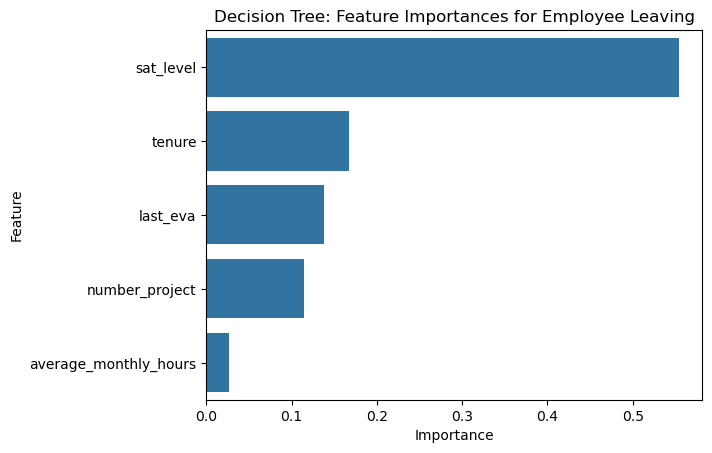

In [ ]:
sns.barplot(data=tree1_importances, x="gini_importance", y=tree1_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()


The barplot above shows that in this decision tree model, `satisfaction_level`, `tenure`, `last_evaluation`, `number_project,`, and `average_monthly_hours` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`.

### Summary of model results

**Logistic Regression**

The logistic regression model achieved precision of 80%, recall of 83%, f1-score of 80% (all weighted averages), and accuracy of 83%, on the test set.

**Tree-based Machine Learning**

After conducting feature engineering, the decision tree model achieved AUC of 93.8%, precision of 87.0%, recall of 90.4%, f1-score of 88.7%, and accuracy of 96.2%, on the test set. The random forest modestly outperformed the decision tree model.

### Conclusion, Recommendations, Next Steps

The models and the feature importances extracted from the models confirm that employees at the company are overworked.

To retain employees, the following recommendations could be presented to the stakeholders:

* Cap the number of projects that employees can work on.
* Consider promoting employees who have been with the company for atleast four years, or conduct further investigation about why four-year tenured employees are so dissatisfied.
* Either reward employees for working longer hours, or don't require them to do so.
* If employees aren't familiar with the company's overtime pay policies, inform them about this. If the expectations around workload and time off aren't explicit, make them clear.
* Hold company-wide and within-team discussions to understand and address the company work culture, across the board and in specific contexts.
* High evaluation scores should not be reserved for employees who work 200+ hours per month. Consider a proportionate scale for rewarding employees who contribute more/put in more effort.

**Next Steps**

It may be justified to still have some concern about data leakage. It could be prudent to consider how predictions change when `satisfaction_level` is removed from the data. It's possible that evaluations aren't performed very frequently, in which case it would be useful to be able to predict employee retention without this feature. It's also possible that the satisfaction score determines whether an employee leaves or stays, in which case it could be useful to pivot and try to predict performance score. The same could be said for evaluation score.

To probe further on this project, you could try building a K-means model on this data and analyzing the clusters. This may yield valuable insight.

### THANK YOU!